# Projeto ETL - Portal da Transparência

Este projeto analisa dados públicos de viagens a serviço do governo federal pegando dados brutos, organizando e transformando em informações mais claras, usando Python, SQL e um banco de dados.

Os dados incluem:
- Viagens
- Pagamentos
- Passagens
- Trechos

E foram processados em três camadas:

- **Raw**: carregamento dos dados brutos sem alterações
- **Silver**: limpeza, padronização e transformação dos dados
- **Gold**: integração e agregação dos dados para análises mais completas

A partir dessas etapas, foram realizadas análises para identificar padrões de custo, frequência e distribuição geográfica das viagens, com o objetivo de gerar insights relevantes sobre o comportamento dos gastos públicos.



### Etapas realizadas:
- Extração de dados
- Transformação e limpeza
- Armazenamento em banco de dados
- Análise exploratória
- Visualização de dados

### Perguntas respondidas:
- Os 5 órgãos com maior custo total? 
- Os 3 destinos com maior custo médio por viagem? 
- A viagem de maior duração e seu custo total? 
- Qual o tipo de pagamento com maior valor médio? 
- Qual o meio de transporte mais usado nos trechos? 
- Qual UF de destino aparece em mais trechos? 
- Qual órgão pagou mais no total? 


Durante a análise, foram identificadas inconsistências nos dados, como registros sigilosos e valores não informados, sendo necessário tratá-los para garantir maior confiabilidade nos resultados.

### Importação das bibliotecas

In [4]:
# Instala as bibliotecas usadas para baixar e ler os arquivos
# Como já está instalado foi colocado o # na frente:

#%pip install gdown pandas

In [1]:
# Bibliotecas usadas para trabalhar com os arquivos
from pathlib import Path
import zipfile
import sys

import gdown
import pandas as pd

# 1. Extração dos dados

Nesta etapa, os dados são baixados e extraídos para leitura em DataFrames.

In [ ]:
# O notebook está dentro da pasta notebooks
pasta_projeto = Path.cwd().parent

# Pasta onde o arquivo zip e os CSVs serão salvos
pasta_dados = pasta_projeto / "data"

# Cria a pasta data caso ela ainda não exista
pasta_dados.mkdir(exist_ok=True)

print(pasta_projeto)
print(pasta_dados)

c:\Users\windows_user\Desktop\Projeto 1 SCTEC
c:\Users\windows_user\Desktop\Projeto 1 SCTEC\data


In [3]:
# Adiciona a pasta principal do projeto aos caminhos (local) de importação
sys.path.append(str(pasta_projeto))

# Importa o ID do arquivo que está salvo no config.py
from config import DRIVE_FILE_ID

In [5]:
# Caminho onde o arquivo baixado será salvo
arquivo_zip = pasta_dados / "dados_viagens_2025.zip"

In [6]:
# Só faz o download quando o arquivo ainda não estiver salvo
if arquivo_zip.exists():
    print("O arquivo já está na pasta data.")
else:
    url = f"https://drive.google.com/uc?id={DRIVE_FILE_ID}"

    print("Baixando o arquivo...")

    resultado = gdown.download(
        url=url,
        output=str(arquivo_zip),
        quiet=False
    )

    if resultado is None:
        raise RuntimeError("Não foi possível baixar o arquivo.")

    print("Download concluído.")

O arquivo já está na pasta data.


In [7]:
# Verifica se o arquivo foi baixado corretamente
if arquivo_zip.exists():
    tamanho_mb = arquivo_zip.stat().st_size / (1024 * 1024)

    print(f"Arquivo: {arquivo_zip.name}")
    print(f"Tamanho: {tamanho_mb:.2f} MB")
    print(f"Local: {arquivo_zip}")
else:
    print("O arquivo não foi encontrado.")

Arquivo: dados_viagens_2025.zip
Tamanho: 64.54 MB
Local: c:\Users\windows_user\Desktop\Projeto 1 SCTEC\data\dados_viagens_2025.zip


In [ ]:
# Pasta onde os arquivos CSV serão extraídos
# Se a pasta ainda não existir, cria a pasta e extrai o conteúdo do ZIP

pasta_csv = pasta_dados / "dados_viagens_2025"
if not pasta_csv.exists():
    pasta_csv.mkdir()

    with zipfile.ZipFile(arquivo_zip, "r") as zip_ref:
        zip_ref.extractall(pasta_csv)

    print("Arquivos extraídos com sucesso.")
else:
    print("Os arquivos já foram extraídos.")

Os arquivos já foram extraídos.


In [9]:
# Lista todos os arquivos CSV encontrados
arquivos_csv = list(pasta_csv.glob("*.csv"))

print("Arquivos encontrados:\n")

for arquivo in arquivos_csv:
    print(arquivo.name)

Arquivos encontrados:

2025_Pagamento.csv
2025_Passagem.csv
2025_Trecho.csv
2025_Viagem.csv


In [10]:
# Lê o arquivo de viagens mantendo todas as colunas como texto
df_viagem = pd.read_csv(
    pasta_csv / "2025_Viagem.csv",
    sep=";",
    encoding="latin-1",
    dtype=str
)

# Mostra as primeiras linhas
df_viagem.head()

,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,...,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos
0,0000000000020261730,000086/25-1C,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26236,Universidade Federal Fluminense,***.834.907-**,...,-1,Sem informação,01/03/2025,04/08/2025,Rio Branco/AC,Desenvolvimento da pesquisa que desenvolvo na ...,"0,00","0,00","0,00","0,00"
1,0000000000020286869,000002/25,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26241,Universidade Federal do Paraná,***.235.999-**,...,FG-0001,FG-0001,25/01/2025,01/02/2025,Palmas/TO,PARTICIPAÇÃO DO XXV ENCONTRO BRASILEIRO DE ICT...,"0,00","2544,74","0,00","0,00"
2,0000000000020289421,000001/25,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.396.790-**,...,OfSuperior,OfSuperior,05/01/2025,07/01/2025,"Bogotá/Colômbia, Uberlândia/MG",Movimentação de militar por término de missão ...,"0,00","4329,72","0,00","1240,09"
3,0000000000020289650,000004/25,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.329.397-**,...,Subtenente,Subtenentes,04/01/2025,06/01/2025,"Londres/Reino Unido, Brasília/DF",Movimentação de militar por término de missão ...,"0,00","7109,73","0,00","1053,53"
4,0000000000020289787,000003/25,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.012.377-**,...,-1,Sem informação,04/01/2025,06/01/2025,"Londres/Reino Unido, Brasília/DF",DEPENDENTE (Esposa) do S Ten Inf ALFREDO DIAS ...,"0,00","7109,73","0,00","0,00"


In [11]:
# Exibe informações gerais sobre o DataFrame
df_viagem.info()

<class 'pandas.DataFrame'>
RangeIndex: 341860 entries, 0 to 341859
Data columns (total 22 columns):
 #   Column                               Non-Null Count   Dtype
---  ------                               --------------   -----
 0   Identificador do processo de viagem  341860 non-null  str  
 1   Número da Proposta (PCDP)            341860 non-null  str  
 2   Situação                             341860 non-null  str  
 3   Viagem Urgente                       341860 non-null  str  
 4   Justificativa Urgência Viagem        341732 non-null  str  
 5   Código do órgão superior             341860 non-null  str  
 6   Nome do órgão superior               341860 non-null  str  
 7   Código órgão solicitante             341860 non-null  str  
 8   Nome órgão solicitante               341860 non-null  str  
 9   CPF viajante                         339294 non-null  str  
 10  Nome                                 341860 non-null  str  
 11  Cargo                                213929 non-nu

In [12]:
# Lê um arquivo CSV mantendo todas as colunas como texto
def ler_csv(nome_arquivo):
    return pd.read_csv(
        pasta_csv / nome_arquivo,
        sep=";",
        encoding="latin-1",
        dtype=str
    )


# Lê os arquivos do Portal da Transparência
df_viagem = ler_csv("2025_Viagem.csv")
df_pagamento = ler_csv("2025_Pagamento.csv")
df_passagem = ler_csv("2025_Passagem.csv")
df_trecho = ler_csv("2025_Trecho.csv")

In [13]:
# Mostra a quantidade de registros de cada arquivo
print(f"Viagens: {len(df_viagem)}")
print(f"Pagamentos: {len(df_pagamento)}")
print(f"Passagens: {len(df_passagem)}")
print(f"Trechos: {len(df_trecho)}")

Viagens: 341860
Pagamentos: 606916
Passagens: 167260
Trechos: 763349


# 2. Transformação dos dados

Nesta etapa, os nomes das colunas são padronizados e os dados são preparados para inserção no banco.

## Padronização das colunas

### Viagem

In [14]:
# Relaciona os nomes das colunas do CSV com os nomes da tabela Raw
colunas_viagem = {
    "Identificador do processo de viagem": "id_viagem",
    "Número da Proposta (PCDP)": "num_proposta",
    "Situação": "situacao",
    "Viagem Urgente": "viagem_urgente",
    "Justificativa Urgência Viagem": "justificativa_urgencia",
    "Código do órgão superior": "cod_orgao_superior",
    "Nome do órgão superior": "nome_orgao_superior",
    "Código órgão solicitante": "cod_orgao_solicitante",
    "Nome órgão solicitante": "nome_orgao_solicitante",
    "CPF viajante": "cpf_viajante",
    "Nome": "nome_viajante",
    "Cargo": "cargo",
    "Função": "funcao",
    "Descrição Função": "descricao_funcao",
    "Período - Data de início": "data_inicio",
    "Período - Data de fim": "data_fim",
    "Destinos": "destinos",
    "Motivo": "motivo",
    "Valor diárias": "valor_diarias",
    "Valor passagens": "valor_passagens",
    "Valor devolução": "valor_devolucao",
    "Valor outros gastos": "valor_outros_gastos"
}

In [15]:
# Renomeia as colunas do DataFrame
df_viagem.rename(columns=colunas_viagem, inplace=True)

### Pagamento

In [16]:
# Relaciona os nomes das colunas do CSV com os nomes da tabela Raw
colunas_pagamento = {
    "Identificador do processo de viagem": "id_viagem",
    "Número da Proposta (PCDP)": "num_proposta",
    "Código do órgão superior": "cod_orgao_superior",
    "Nome do órgão superior": "nome_orgao_superior",
    "Código órgão pagador": "cod_orgao_pagador",
    "Nome órgão pagador": "nome_orgao_pagador",
    "Código UG pagadora": "cod_ug_pagadora",
    "Nome UG pagadora": "nome_ug_pagadora",
    "Tipo de pagamento": "tipo_pagamento",
    "Valor": "valor"
}

# Renomeia as colunas do DataFrame
df_pagamento.rename(columns=colunas_pagamento, inplace=True)

### Passagem

In [17]:
# Relaciona os nomes das colunas do CSV com os nomes da tabela Raw
colunas_passagem = {
    "Identificador do processo de viagem": "id_viagem",
    "Número da Proposta (PCDP)": "num_proposta",
    "Meio de transporte": "meio_transporte",
    "País Origem Ida": "pais_origem_ida",
    "UF Origem Ida": "uf_origem_ida",
    "Cidade Origem Ida": "cidade_origem_ida",
    "País Destino Ida": "pais_destino_ida",
    "UF Destino Ida": "uf_destino_ida",
    "Cidade Destino Ida": "cidade_destino_ida",
    "País Origem Volta": "pais_origem_volta",
    "UF Origem Volta": "uf_origem_volta",
    "Cidade Origem Volta": "cidade_origem_volta",
    "País Destino Volta": "pais_destino_volta",
    "UF Destino Volta": "uf_destino_volta",
    "Cidade Destino Volta": "cidade_destino_volta",
    "Valor da passagem": "valor_passagem",
    "Taxa de serviço": "taxa_servico",
    "Data de emissão": "data_emissao",
    "Hora de emissão": "hora_emissao"
}

# Renomeia as colunas do DataFrame
df_passagem.rename(columns=colunas_passagem, inplace=True)

### Trecho

In [18]:
# Relaciona os nomes das colunas do CSV com os nomes da tabela Raw
colunas_trecho = {
    "Identificador do processo de viagem": "id_viagem",
    "Número da Proposta (PCDP)": "num_proposta",
    "Sequência do trecho": "sequencia_trecho",
    "Origem - Data": "origem_data",
    "Origem - País": "origem_pais",
    "Origem - UF": "origem_uf",
    "Origem - Cidade": "origem_cidade",
    "Destino - Data": "destino_data",
    "Destino - País": "destino_pais",
    "Destino - UF": "destino_uf",
    "Destino - Cidade": "destino_cidade",
    "Meio de transporte": "meio_transporte",
    "Número de diárias": "numero_diarias",
    "Missão": "missao"
}

# Renomeia as colunas do DataFrame
df_trecho.rename(columns=colunas_trecho, inplace=True)

In [19]:
# Exibe as colunas de cada DataFrame
print("Viagem:")
print(df_viagem.columns.tolist())

print("\nPagamento:")
print(df_pagamento.columns.tolist())

print("\nPassagem:")
print(df_passagem.columns.tolist())

print("\nTrecho:")
print(df_trecho.columns.tolist())

Viagem:
['id_viagem', 'num_proposta', 'situacao', 'viagem_urgente', 'justificativa_urgencia', 'cod_orgao_superior', 'nome_orgao_superior', 'cod_orgao_solicitante', 'nome_orgao_solicitante', 'cpf_viajante', 'nome_viajante', 'cargo', 'funcao', 'descricao_funcao', 'data_inicio', 'data_fim', 'destinos', 'motivo', 'valor_diarias', 'valor_passagens', 'valor_devolucao', 'valor_outros_gastos']

Pagamento:
['id_viagem', 'num_proposta', 'cod_orgao_superior', 'nome_orgao_superior', 'Codigo do órgão pagador', 'Nome do órgao pagador', 'Código da unidade gestora pagadora', 'Nome da unidade gestora pagadora', 'tipo_pagamento', 'valor']

Passagem:
['id_viagem', 'num_proposta', 'meio_transporte', 'País - Origem ida', 'UF - Origem ida', 'Cidade - Origem ida', 'País - Destino ida', 'UF - Destino ida', 'Cidade - Destino ida', 'País - Origem volta', 'UF - Origem volta', 'Cidade - Origem volta', 'Pais - Destino volta', 'UF - Destino volta', 'Cidade - Destino volta', 'valor_passagem', 'taxa_servico', 'Data d

## Conexão com o banco de dados

Nesta etapa, é realizada a conexão com o banco de dados MySQL, que será utilizada para armazenar os dados da camada Raw.

In [20]:
# Importa a função responsável pela conexão com o banco
from banco import conectar

## Preparação dos dados para inserção

Antes de inserir os registros no banco de dados, é necessário verificar o formato dos dados e adaptá-los para a estrutura esperada pelo MySQL.

Nesta etapa, serão realizadas conversões e preparações para a inserção em lote dos registros.

In [23]:
# Transforma o primeiro registro em uma tupla
tuple(df_viagem.iloc[0])

('0000000000020261730',
 '000086/25-1C',
 'Realizada',
 'NÃO',
 'Sem informação',
 '26000',
 'Ministério da Educação',
 '26236',
 'Universidade Federal Fluminense',
 '***.834.907-**',
 'NAZIRA CORREIA CAMELY',
 'PROFESSOR DO MAGISTERIO SUPERIOR',
 '-1',
 'Sem informação',
 '01/03/2025',
 '04/08/2025',
 'Rio Branco/AC',
 'Desenvolvimento da pesquisa que desenvolvo na UFF.. Estágio de Pós-Doutorado na UFAC.',
 '0,00',
 '0,00',
 '0,00',
 '0,00')

## 3. Carregamento dos dados (Load)

Inserção dos dados nas tabelas Raw do MySQL utilizando processamento em lote.

## Inserção dos dados nas tabelas Raw

Após preparar os registros, inicia-se a etapa de carregamento (Load) do processo ETL.

Nesta etapa, os dados serão inseridos nas tabelas da camada **Raw** do banco de dados MySQL utilizando inserção em lote, tornando o processo mais eficiente.

In [25]:
# Importa a função de inserção e o tamanho definido para cada bloco
from banco import inserir_em_lote
from config import TAMANHO_BLOCO

### Preparação da tabela raw_viagem

In [ ]:
#Inserção dos registros na tabela raw_viagem
sql_viagem = """
INSERT INTO raw_viagem (
    id_viagem,
    num_proposta,
    situacao,
    viagem_urgente,
    cod_orgao_superior,
    nome_orgao_superior,
    nome_viajante,
    cargo,
    data_inicio,
    data_fim,
    destinos,
    motivo,
    valor_diarias,
    valor_passagens,
    valor_devolucao,
    valor_outros_gastos
)
VALUES (
    %s, %s, %s, %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s, %s, %s, %s
)
"""

In [29]:
# Seleciona as colunas que existem na tabela raw_viagem
colunas_raw_viagem = [
    "id_viagem",
    "num_proposta",
    "situacao",
    "viagem_urgente",
    "cod_orgao_superior",
    "nome_orgao_superior",
    "nome_viajante",
    "cargo",
    "data_inicio",
    "data_fim",
    "destinos",
    "motivo",
    "valor_diarias",
    "valor_passagens",
    "valor_devolucao",
    "valor_outros_gastos"
]

In [30]:
# Seleciona as colunas usadas na tabela
df_viagem_banco = df_viagem[colunas_raw_viagem].astype(object)

# Substitui valores ausentes por None
df_viagem_banco = df_viagem_banco.where(
    pd.notna(df_viagem_banco),
    None
)

# Converte os registros tratados em uma lista de tuplas
linhas_viagem = list(
    df_viagem_banco.itertuples(index=False, name=None)
)

In [31]:
# Insere os registros em blocos
conexao = conectar()

try:
    for inicio in range(0, len(linhas_viagem), TAMANHO_BLOCO):
        fim = inicio + TAMANHO_BLOCO
        bloco = linhas_viagem[inicio:fim]

        inserir_em_lote(
            conexao,
            sql_viagem,
            bloco
        )

        print(
            f"Registros {inicio + 1} até "
            f"{min(fim, len(linhas_viagem))} inseridos."
        )

    print("Inserção da tabela raw_viagem concluída.")

finally:
    conexao.close()

Registros 1 até 50000 inseridos.
Registros 50001 até 100000 inseridos.
Registros 100001 até 150000 inseridos.
Registros 150001 até 200000 inseridos.
Registros 200001 até 250000 inseridos.
Registros 250001 até 300000 inseridos.
Registros 300001 até 341860 inseridos.
Inserção da tabela raw_viagem concluída.


## Preparação da tabela raw_pagamento

In [ ]:


df_pagamento = df_pagamento.rename(
    columns={
        "Codigo do órgão pagador": "cod_orgao_pagador",
        "Nome do órgao pagador": "nome_orgao_pagador",
        "Código da unidade gestora pagadora": "cod_ug_pagadora",
        "Nome da unidade gestora pagadora": "nome_ug_pagadora"
    }
)

In [ ]:
# Seleciona as colunas que existem na tabela raw_pagamento

colunas_raw_pagamento = [
    "id_viagem",
    "num_proposta",
    "cod_orgao_superior",
    "nome_orgao_superior",
    "cod_orgao_pagador",
    "nome_orgao_pagador",
    "cod_ug_pagadora",
    "nome_ug_pagadora",
    "tipo_pagamento",
    "valor"
]

In [ ]:
# Seleciona as colunas usadas na tabela
df_pagamento_banco = df_pagamento[colunas_raw_pagamento].astype(object)

# Substitui valores ausentes por None
df_pagamento_banco = df_pagamento_banco.where(
    pd.notna(df_pagamento_banco),
    None
)

# Converte os registros tratados em uma lista de tuplas
linhas_pagamento = list(
    df_pagamento_banco.itertuples(index=False, name=None)
)

In [ ]:
# Comando SQL usado para inserir registros na tabela raw_pagamento

sql_pagamento = """
    INSERT INTO raw_pagamento (
        id_viagem,
        num_proposta,
        cod_orgao_superior,
        nome_orgao_superior,
        cod_orgao_pagador,
        nome_orgao_pagador,
        cod_ug_pagadora,
        nome_ug_pagadora,
        tipo_pagamento,
        valor
    )
    VALUES (
        %s, %s, %s, %s, %s,
        %s, %s, %s, %s, %s
    )
"""

In [41]:
# Insere os registros de pagamento em blocos
conexao = conectar()

try:
    for inicio in range(0, len(linhas_pagamento), TAMANHO_BLOCO):
        fim = inicio + TAMANHO_BLOCO
        bloco = linhas_pagamento[inicio:fim]

        inserir_em_lote(
            conexao,
            sql_pagamento,
            bloco
        )

        print(
            f"Registros {inicio + 1} até "
            f"{min(fim, len(linhas_pagamento))} inseridos."
        )

    print("Inserção da tabela raw_pagamento concluída.")

finally:
    conexao.close()

Registros 1 até 50000 inseridos.
Registros 50001 até 100000 inseridos.
Registros 100001 até 150000 inseridos.
Registros 150001 até 200000 inseridos.
Registros 200001 até 250000 inseridos.
Registros 250001 até 300000 inseridos.
Registros 300001 até 350000 inseridos.
Registros 350001 até 400000 inseridos.
Registros 400001 até 450000 inseridos.
Registros 450001 até 500000 inseridos.
Registros 500001 até 550000 inseridos.
Registros 550001 até 600000 inseridos.
Registros 600001 até 606916 inseridos.
Inserção da tabela raw_pagamento concluída.


## Preparação da tabela raw_passagem

In [43]:
df_passagem = df_passagem.rename(
    columns={
        "País - Origem ida": "pais_origem_ida",
        "UF - Origem ida": "uf_origem_ida",
        "Cidade - Origem ida": "cidade_origem_ida",
        "País - Destino ida": "pais_destino_ida",
        "UF - Destino ida": "uf_destino_ida",
        "Cidade - Destino ida": "cidade_destino_ida",

        "País - Origem volta": "pais_origem_volta",
        "UF - Origem volta": "uf_origem_volta",
        "Cidade - Origem volta": "cidade_origem_volta",

        # aqui tem um detalhe: "Pais" sem acento
        "Pais - Destino volta": "pais_destino_volta",
        "UF - Destino volta": "uf_destino_volta",
        "Cidade - Destino volta": "cidade_destino_volta",

        "Data da emissão/compra": "data_emissao",
        "Hora da emissão/compra": "hora_emissao"
    }
)

In [44]:
colunas_raw_passagem = [
    "id_viagem",
    "num_proposta",
    "meio_transporte",
    "pais_origem_ida",
    "uf_origem_ida",
    "cidade_origem_ida",
    "pais_destino_ida",
    "uf_destino_ida",
    "cidade_destino_ida",
    "pais_origem_volta",
    "uf_origem_volta",
    "cidade_origem_volta",
    "pais_destino_volta",
    "uf_destino_volta",
    "cidade_destino_volta",
    "valor_passagem",
    "taxa_servico",
    "data_emissao",
    "hora_emissao"
]

In [47]:
colunas_raw_passagem = [
    "id_viagem",
    "num_proposta",
    "meio_transporte",
    "pais_origem_ida",
    "uf_origem_ida",
    "cidade_origem_ida",
    "pais_destino_ida",
    "uf_destino_ida",
    "cidade_destino_ida",
    "pais_origem_volta",
    "uf_origem_volta",
    "cidade_origem_volta",
    "pais_destino_volta",
    "uf_destino_volta",
    "cidade_destino_volta",
    "valor_passagem",
    "taxa_servico",
    "data_emissao",
    "hora_emissao"
]

In [48]:
df_passagem_banco = df_passagem[colunas_raw_passagem].astype(object)

df_passagem_banco = df_passagem_banco.where(
    pd.notna(df_passagem_banco),
    None
)

linhas_passagem = list(
    df_passagem_banco.itertuples(index=False, name=None)
)

In [ ]:
# Inserção dos registros na tabela raw_passagem

sql_passagem = """
    INSERT INTO raw_passagem (
        id_viagem,
        num_proposta,
        meio_transporte,
        pais_origem_ida,
        uf_origem_ida,
        cidade_origem_ida,
        pais_destino_ida,
        uf_destino_ida,
        cidade_destino_ida,
        pais_origem_volta,
        uf_origem_volta,
        cidade_origem_volta,
        pais_destino_volta,
        uf_destino_volta,
        cidade_destino_volta,
        valor_passagem,
        taxa_servico,
        data_emissao,
        hora_emissao
    )
    VALUES (
        %s, %s, %s, %s, %s, %s, %s, %s, %s,
        %s, %s, %s, %s, %s, %s, %s, %s, %s, %s
    )
"""

In [ ]:
# Insere os registros de pagamento em blocos

conexao = conectar()

try:
    for inicio in range(0, len(linhas_passagem), TAMANHO_BLOCO):
        fim = inicio + TAMANHO_BLOCO
        bloco = linhas_passagem[inicio:fim]

        inserir_em_lote(
            conexao,
            sql_passagem,
            bloco
        )

        print(
            f"Registros {inicio + 1} até "
            f"{min(fim, len(linhas_passagem))} inseridos."
        )

    print("Inserção da tabela raw_passagem concluída.")

finally:
    conexao.close()

Registros 1 até 50000 inseridos.
Registros 50001 até 100000 inseridos.
Registros 100001 até 150000 inseridos.
Registros 150001 até 167260 inseridos.
Inserção da tabela raw_passagem concluída.


## Preparação da tabela raw_trecho

In [60]:
df_trecho = df_trecho.rename(
    columns={
        "Identificador do processo de viagem ": "id_viagem",
        "Sequência Trecho": "sequencia_trecho",
        "Número Diárias": "numero_diarias",
        "Missao?": "missao"
    }
)

In [61]:
colunas_raw_trecho = [
    "id_viagem",
    "num_proposta",
    "sequencia_trecho",
    "origem_data",
    "origem_pais",
    "origem_uf",
    "origem_cidade",
    "destino_data",
    "destino_pais",
    "destino_uf",
    "destino_cidade",
    "meio_transporte",
    "numero_diarias",
    "missao"
]

In [62]:
df_trecho_banco = df_trecho[colunas_raw_trecho].astype(object)

df_trecho_banco = df_trecho_banco.where(
    pd.notna(df_trecho_banco),
    None
)

linhas_trecho = list(
    df_trecho_banco.itertuples(index=False, name=None)
)

In [ ]:
# Comando SQL usado para inserir registros na tabela raw_trecho

sql_trecho = """
    INSERT INTO raw_trecho (
        id_viagem,
        num_proposta,
        sequencia_trecho,
        origem_data,
        origem_pais,
        origem_uf,
        origem_cidade,
        destino_data,
        destino_pais,
        destino_uf,
        destino_cidade,
        meio_transporte,
        numero_diarias,
        missao
    )
    VALUES (
        %s, %s, %s, %s, %s, %s, %s,
        %s, %s, %s, %s, %s, %s, %s
    )
"""

In [64]:
# Insere os registros de pagamento em blocos

conexao = conectar()

try:
    for inicio in range(0, len(linhas_trecho), TAMANHO_BLOCO):
        fim = inicio + TAMANHO_BLOCO
        bloco = linhas_trecho[inicio:fim]

        inserir_em_lote(
            conexao,
            sql_trecho,
            bloco
        )

        print(
            f"Registros {inicio + 1} até "
            f"{min(fim, len(linhas_trecho))} inseridos."
        )

    print("Inserção da tabela raw_trecho concluída.")

finally:
    conexao.close()

Registros 1 até 50000 inseridos.
Registros 50001 até 100000 inseridos.
Registros 100001 até 150000 inseridos.
Registros 150001 até 200000 inseridos.
Registros 200001 até 250000 inseridos.
Registros 250001 até 300000 inseridos.
Registros 300001 até 350000 inseridos.
Registros 350001 até 400000 inseridos.
Registros 400001 até 450000 inseridos.
Registros 450001 até 500000 inseridos.
Registros 500001 até 550000 inseridos.
Registros 550001 até 600000 inseridos.
Registros 600001 até 650000 inseridos.
Registros 650001 até 700000 inseridos.
Registros 700001 até 750000 inseridos.
Registros 750001 até 763349 inseridos.
Inserção da tabela raw_trecho concluída.


# 4. Análise dos dados

Nesta etapa, são realizadas consultas SQL para explorar os dados carregados no banco e gerar insights.

## Análise Silver

### Pergunta 1 - Quais os 5 órgãos com maior custo total?

In [67]:
# Consulta SQL para calcular o custo total por órgão
# Soma: passagens + diárias + outros gastos - devoluções
# Conversão necessária: valores estão como string com vírgula

query_orgaos = """
SELECT 
    nome_orgao_superior,
    SUM(
        CAST(REPLACE(valor_passagens, ',', '.') AS DECIMAL(10,2)) +
        CAST(REPLACE(valor_diarias, ',', '.') AS DECIMAL(10,2)) +
        CAST(REPLACE(valor_outros_gastos, ',', '.') AS DECIMAL(10,2)) -
        CAST(REPLACE(valor_devolucao, ',', '.') AS DECIMAL(10,2))
    ) AS custo_total
FROM raw_viagem
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5;
"""

In [68]:
# Executa a consulta no banco e retorna o resultado em DataFrame

conexao = conectar()

try:
    df_orgaos = pd.read_sql(query_orgaos, conexao)
finally:
    conexao.close()

# Exibe o resultado
df_orgaos

C:\Users\windows_user\AppData\Local\Temp\ipykernel_11196\183922806.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_orgaos = pd.read_sql(query_orgaos, conexao)


,nome_orgao_superior,custo_total
0,Ministério da Justiça e Segurança Pública,4.869331e+08
1,Ministério da Defesa,1.560703e+08
2,Ministério da Educação,1.112913e+08
3,Ministério do Meio Ambiente e Mudança do Clima,4.969771e+07
4,Ministério da Previdência Social,4.041731e+07


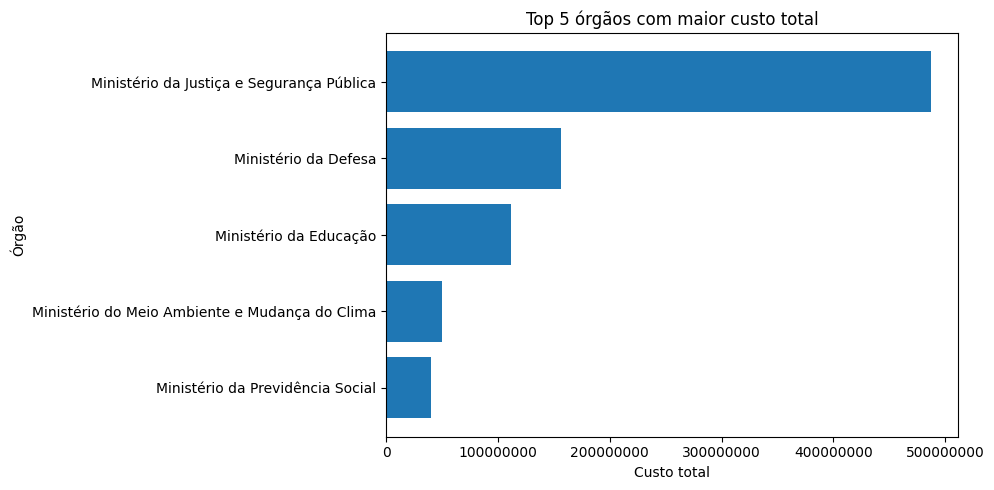

In [72]:
# Ordena do menor para o maior (fica melhor visualmente)
df_orgaos_plot = df_orgaos.sort_values("custo_total")

# Cria gráfico horizontal
plt.figure(figsize=(10,5))

plt.barh(df_orgaos_plot["nome_orgao_superior"], df_orgaos_plot["custo_total"])

plt.ticklabel_format(style='plain', axis='x')

plt.title("Top 5 órgãos com maior custo total")
plt.xlabel("Custo total")
plt.ylabel("Órgão")

plt.tight_layout()
plt.show()

O Ministério da Justiça e Segurança Pública apresenta um custo significativamente maior que os demais, indicando maior volume ou frequência de deslocamentos. Os demais órgãos apresentam valores consideravelmente inferiores, com distribuição mais equilibrada entre si.

### Pergunta 2 - Quais os 3 destinos com maior custo médio por viagem?

Ao realizar a análise inicial, foi observado que os destinos com maior custo médio possuíam apenas uma viagem registrada, o que compromete a confiabilidade da média calculada.

Para garantir maior confiabilidade na análise, foram considerados apenas destinos com pelo menos 5 viagens registradas, evitando distorções causadas por baixa quantidade de dados.

Após aplicar o filtro de quantidade mínima de viagens, é possível notar que determinados destinos apresentam custo médio elevado por viagem, indicando deslocamentos potencialmente mais longos ou com maior complexidade logística. A utilização do critério mínimo de ocorrências torna a análise mais confiável e representativa.

Os destinos com apenas uma ocorrência podem apresentar valores elevados, porém não representam um padrão consistente, sendo considerados outliers na análise.

In [85]:
# Consulta SQL para calcular o custo médio por viagem em cada destino

query_destinos = """
SELECT 
    destinos,
    ROUND(AVG(
        CAST(REPLACE(valor_passagens, ',', '.') AS DECIMAL(10,2)) +
        CAST(REPLACE(valor_diarias, ',', '.') AS DECIMAL(10,2)) +
        CAST(REPLACE(valor_outros_gastos, ',', '.') AS DECIMAL(10,2)) -
        CAST(REPLACE(valor_devolucao, ',', '.') AS DECIMAL(10,2))
    ), 2) AS custo_medio_viagem,
    COUNT(*) AS total_viagens
FROM raw_viagem
GROUP BY destinos
HAVING COUNT(*) >= 5
ORDER BY custo_medio_viagem DESC
LIMIT 3;
"""

In [87]:
# Executa a consulta no banco e retorna o resultado em DataFrame

conexao = conectar()

try:
    df_destinos = pd.read_sql(query_destinos, conexao)
finally:
    conexao.close()

# Exibe o resultado
df_destinos

C:\Users\windows_user\AppData\Local\Temp\ipykernel_11196\3712047770.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_destinos = pd.read_sql(query_destinos, conexao)


,destinos,custo_medio_viagem,total_viagens
0,"Brasília/DF, Brasília/DF, Brasília/DF, Brasíli...",114692.39,5
1,"Brasília/DF, Brasília/DF, Brasília/DF, Brasíli...",114142.97,13
2,"Brasília/DF, Brasília/DF, Brasília/DF, Brasíli...",109081.97,26


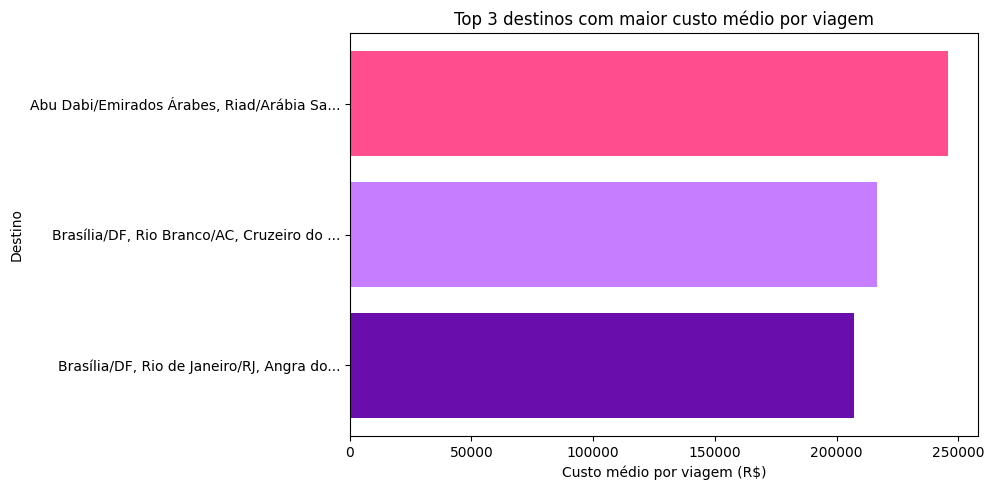

In [86]:
# Ordena para melhor visualização
df_destinos_plot = df_destinos.sort_values("custo_medio_viagem")
df_destinos_plot["destinos"] = df_destinos_plot["destinos"].str[:40] + "..."

plt.figure(figsize=(10,5))

# Degradê roxo → rosa
cores = ["#6a0dad", "#c77dff", "#ff4d8d"]

plt.barh(
    df_destinos_plot["destinos"],
    df_destinos_plot["custo_medio_viagem"],
    color=cores
)

plt.title("Top 3 destinos com maior custo médio por viagem")
plt.xlabel("Custo médio por viagem (R$)")
plt.ylabel("Destino")

plt.tight_layout()
plt.show()

Filtrando os destinos com maior número de viagens, se nota que os custos médios mais elevados estão associados a deslocamentos mais específicos, possivelmente envolvendo maior distância ou complexidade logística. Diferentemente da análise inicial, esses resultados apresentam maior confiabilidade estatística.

### Pergunta 3 - Qual a viagem de maior duração e seu custo total?

In [88]:
# Consulta SQL para encontrar a viagem com maior duração
# Converte as datas e calcula a diferença entre início e fim
# Também calcula o custo total da viagem

query_duracao = """
SELECT 
    id_viagem,
    nome_viajante,
    destinos,
    DATEDIFF(
        STR_TO_DATE(data_fim, '%d/%m/%Y'),
        STR_TO_DATE(data_inicio, '%d/%m/%Y')
    ) AS duracao_dias,
    (
        CAST(REPLACE(valor_passagens, ',', '.') AS DECIMAL(10,2)) +
        CAST(REPLACE(valor_diarias, ',', '.') AS DECIMAL(10,2)) +
        CAST(REPLACE(valor_outros_gastos, ',', '.') AS DECIMAL(10,2)) -
        CAST(REPLACE(valor_devolucao, ',', '.') AS DECIMAL(10,2))
    ) AS custo_total
FROM raw_viagem
ORDER BY duracao_dias DESC
LIMIT 1;
"""

In [89]:
# Executa a consulta e retorna o resultado em DataFrame

conexao = conectar()

try:
    df_duracao = pd.read_sql(query_duracao, conexao)
finally:
    conexao.close()

df_duracao

C:\Users\windows_user\AppData\Local\Temp\ipykernel_11196\986360860.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_duracao = pd.read_sql(query_duracao, conexao)


,id_viagem,nome_viajante,destinos,duracao_dias,custo_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,Mogi Mirim/SP,383,0.0


In [103]:
from IPython.display import display, HTML

viagem = df_duracao.iloc[0]

display(HTML(f"""
<div style="
    background: linear-gradient(135deg, #ffe5ec, #ffc2d1);
    padding: 20px;
    border-radius: 12px;
    color: #4a1c2b;
    font-family: Arial;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
">
    <h3 style="margin-top: 0; border-bottom: 1px solid #ff8fab; padding-bottom: 8px;">
        Viagem de maior duração
    </h3>
    
    <p><strong>ID da viagem:</strong> {viagem['id_viagem']}</p>
    <p><strong>Viajante:</strong> {viagem['nome_viajante']}</p>
    <p><strong>Destino:</strong> {viagem['destinos']}</p>
    <p style="font-size: 18px;"><strong>Duração:</strong> {viagem['duracao_dias']} dias</p>
    <p><strong>Custo total:</strong> R$ {viagem['custo_total']:.2f}</p>
</div>
"""))

A análise identificou uma viagem com duração significativamente superior às demais, indicando um deslocamento prolongado. Esse tipo de viagem pode estar associado a atividades de longa permanência, como capacitações, projetos institucionais ou missões específicas. O custo total acompanha essa duração estendida.

O resultado pode indicar ausência de registro de custos associados à viagem, e não necessariamente que a viagem não gerou despesa ou estar relacionado a ausência de registros de despesas na base analisada, utilização de recursos institucionais sem custo direto ou inconsistências nos dados. Portanto, a análise de custo deve ser interpretada com cautela nesse caso.

### Pergunta 4 -  Qual o tipo de pagamento com maior valor médio?

In [93]:
# Consulta SQL para calcular o valor médio por tipo de pagamento
# Converte o valor de string para número antes de calcular a média

query_pagamento = """
SELECT 
    tipo_pagamento,
    ROUND(AVG(
        CAST(REPLACE(valor, ',', '.') AS DECIMAL(10,2))
    ), 2) AS valor_medio,
    COUNT(*) AS quantidade
FROM raw_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
"""

In [94]:
# Executa a consulta e retorna o resultado em DataFrame

conexao = conectar()

try:
    df_pagamento = pd.read_sql(query_pagamento, conexao)
finally:
    conexao.close()

df_pagamento

C:\Users\windows_user\AppData\Local\Temp\ipykernel_11196\579315256.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pagamento = pd.read_sql(query_pagamento, conexao)


,tipo_pagamento,valor_medio,quantidade
0,DIÁRIAS,2078.28,401463
1,PASSAGEM,1878.34,188985
2,Serviço correlato: seguro,447.51,4894
3,RESTITUIÇÃO,245.70,11574


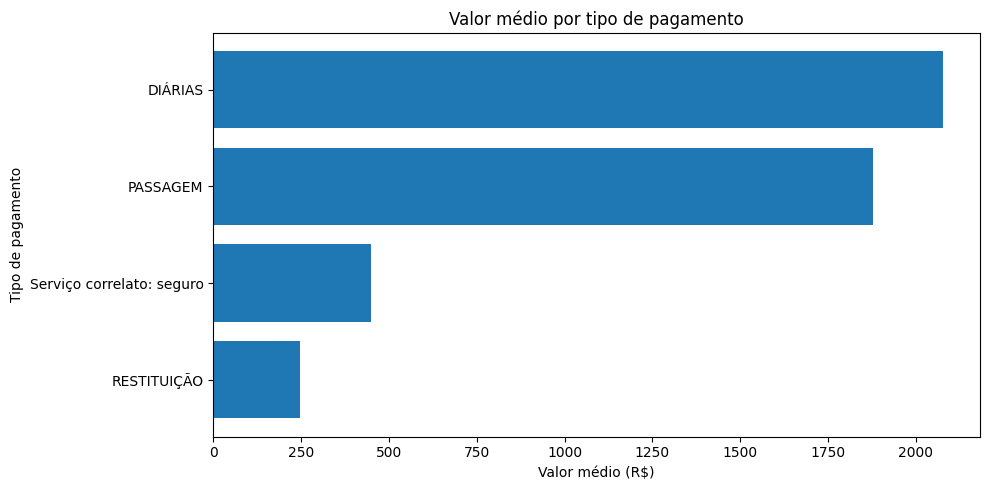

In [95]:
# Ordena para melhor visualização
df_pagamento_plot = df_pagamento.sort_values("valor_medio")

plt.figure(figsize=(10,5))

plt.barh(
    df_pagamento_plot["tipo_pagamento"],
    df_pagamento_plot["valor_medio"]
)

plt.title("Valor médio por tipo de pagamento")
plt.xlabel("Valor médio (R$)")
plt.ylabel("Tipo de pagamento")

plt.tight_layout()
plt.show()

Determinados tipos de pagamento apresentam valor médio significativamente superior aos demais, indicando diferenças no tipo de despesa associada. Pagamentos relacionados a passagens, por exemplo, tendem a apresentar valores médios mais elevados em comparação a outros tipos, refletindo custos logísticos mais altos.

### Pergunta 5 - Qual o meio de transporte mais utilizado nos trechos?

In [96]:
# Consulta SQL para identificar o meio de transporte mais utilizado
# Conta quantas vezes cada meio de transporte aparece

query_transporte = """
SELECT 
    meio_transporte,
    COUNT(*) AS total_uso
FROM raw_trecho
GROUP BY meio_transporte
ORDER BY total_uso DESC;
"""

In [97]:
# Executa a consulta e retorna o resultado em DataFrame

conexao = conectar()

try:
    df_transporte = pd.read_sql(query_transporte, conexao)
finally:
    conexao.close()

df_transporte

C:\Users\windows_user\AppData\Local\Temp\ipykernel_11196\4073261624.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_transporte = pd.read_sql(query_transporte, conexao)


,meio_transporte,total_uso
0,Veículo Oficial,772848
1,Aéreo,465332
2,Rodoviário,129940
3,Veículo Próprio,85692
4,Inválido,53318
5,Fluvial,16858
6,Ferroviário,1748
7,Marítimo,962


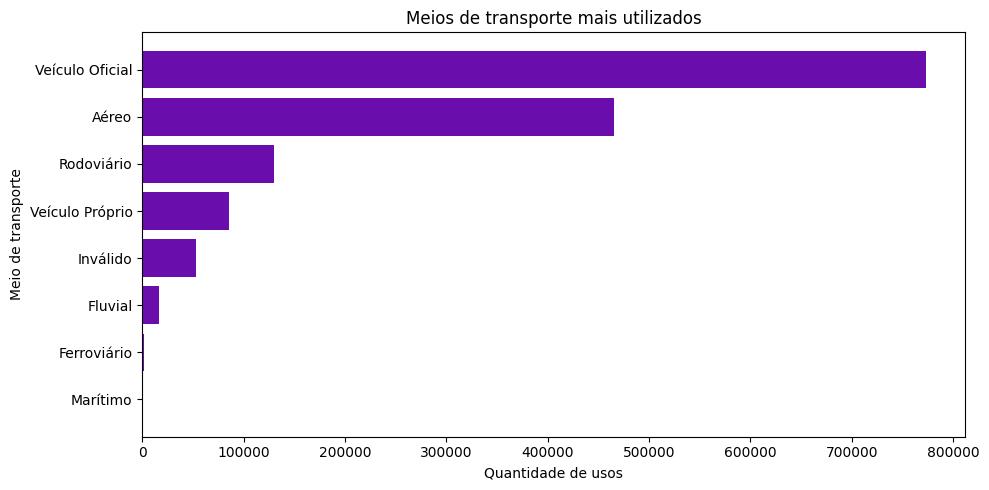

In [99]:
# Ordena para melhor visualização
df_transporte_plot = df_transporte.sort_values("total_uso")

plt.figure(figsize=(10,5))

plt.barh(
    df_transporte_plot["meio_transporte"],
    df_transporte_plot["total_uso"],
    color="#6a0dad"  # roxo principal
)

plt.title("Meios de transporte mais utilizados")
plt.xlabel("Quantidade de usos")
plt.ylabel("Meio de transporte")

plt.tight_layout()
plt.show()

Veículos oficiais apresentam predominância significativa em relação aos demais, indicando um padrão claro de deslocamento. Esse comportamento pode estar associado à logística institucional, custos envolvidos ou à natureza das viagens realizadas.

### Pergunta 6 - Qual UF de destino aparece com mais frequência?

In [100]:
# Consulta SQL para identificar a UF de destino mais frequente
# Conta quantas vezes cada UF aparece nos trechos

query_uf = """
SELECT 
    destino_uf,
    COUNT(*) AS total
FROM raw_trecho
GROUP BY destino_uf
ORDER BY total DESC;
"""

In [101]:
# Executa a consulta e retorna o resultado em DataFrame

conexao = conectar()

try:
    df_uf = pd.read_sql(query_uf, conexao)
finally:
    conexao.close()

df_uf

C:\Users\windows_user\AppData\Local\Temp\ipykernel_11196\320699565.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_uf = pd.read_sql(query_uf, conexao)


,destino_uf,total
0,São Paulo,165444
1,Distrito Federal,159924
2,Minas Gerais,101930
3,Rio de Janeiro,88394
4,Paraná,85206
5,Pará,80088
6,Rio Grande do Sul,77368
7,Mato Grosso do Sul,61032
8,Bahia,56750
9,Pernambuco,56744


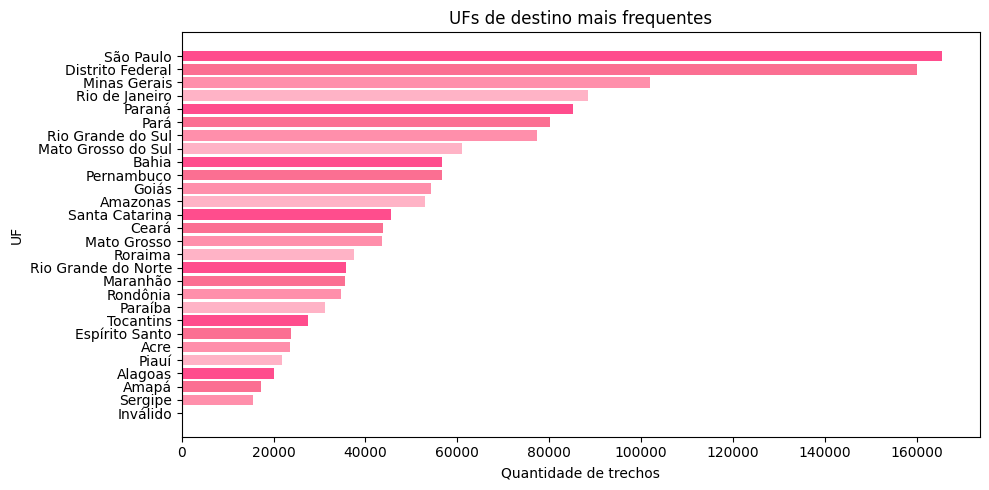

In [104]:
# Remove valores nulos da coluna de UF
df_uf_plot = df_uf.dropna(subset=["destino_uf"])

# Ordena para melhor visualização
df_uf_plot = df_uf_plot.sort_values("total")

plt.figure(figsize=(10,5))


cores = ["#ffb3c6", "#ff8fab", "#fb6f92", "#ff4d8d"]

plt.barh(
    df_uf_plot["destino_uf"],
    df_uf_plot["total"],
    color=cores[:len(df_uf_plot)]
)

plt.title("UFs de destino mais frequentes")
plt.xlabel("Quantidade de trechos")
plt.ylabel("UF")

plt.tight_layout()
plt.show()

São Paulo se destaca com maior volume como destino, esse padrão indica centralização de deslocamentos em polos econômicos e administrativos.

Também foi identificada a presença de registros classificados como "Inválido", sugerindo inconsistências ou problemas de qualidade nos dados, que devem ser considerados na interpretação dos resultados.

### Pergunta 7 - Qual órgão possui maior gasto total?

Durante a análise, foram identificados registros classificados como "Sigiloso" e "Sem Informação", que não representam órgãos específicos.

Esses registros foram desconsiderados para evitar distorções nos resultados.

In [129]:
# Consulta SQL para identificar o órgão que mais gastou no total

query_p7 = """
SELECT 
    nome_orgao_pagador,
    SUM(CAST(REPLACE(valor, ',', '.') AS DECIMAL(10,2))) AS total_gasto
FROM raw_pagamento
WHERE LOWER(TRIM(nome_orgao_pagador)) NOT IN ('sigiloso', 'sem informação')
GROUP BY nome_orgao_pagador
ORDER BY total_gasto DESC
LIMIT 10;
"""

In [130]:
# Executa a consulta e retorna o resultado em DataFrame

conexao = conectar()

try:
    df_orgao_pagador = pd.read_sql(query_p7, conexao)
finally:
    conexao.close()

df_orgao_pagador

C:\Users\windows_user\AppData\Local\Temp\ipykernel_11196\3833794575.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_orgao_pagador = pd.read_sql(query_p7, conexao)


,nome_orgao_pagador,total_gasto
0,Fundo Nacional de Segurança Pública,2.784810e+08
1,Comando da Aeronáutica,8.176914e+07
2,Instituto Nacional do Seguro Social,3.742760e+07
3,Comando do Exército,3.687264e+07
4,Ministério da Gestão e da Inovação em Serviços...,3.554176e+07
5,Instituto Brasileiro do Meio Ambiente e dos Re...,3.158985e+07
6,Ministério das Relações Exteriores - Unidades ...,2.560538e+07
7,Receita Federal do Brasil,2.381103e+07
8,Ministério da Agricultura e Pecuária - Unidade...,2.289988e+07
9,Ministério da Defesa - Unidades com vínculo di...,2.098408e+07


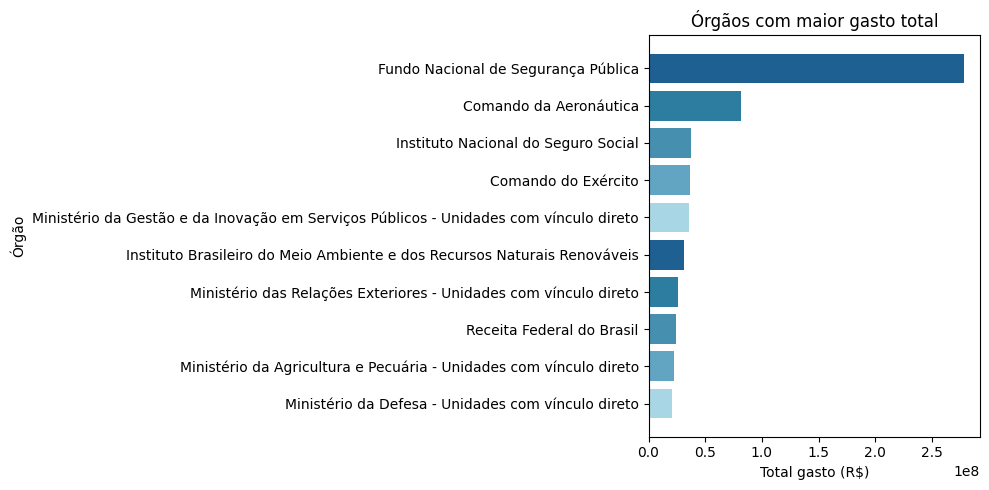

In [131]:
# Seleciona os 10 maiores gastos
df_orgao_pagador_plot = df_orgao_pagador.sort_values("total_gasto").tail(10)

plt.figure(figsize=(10,5))

# Paleta em tons de azul (elegante)
cores = ["#a9d6e5", "#61a5c2", "#468faf", "#2c7da0", "#1e6091"]

plt.barh(
    df_orgao_pagador_plot["nome_orgao_pagador"],
    df_orgao_pagador_plot["total_gasto"],
    color=cores[:len(df_orgao_pagador_plot)]
)

plt.title("Órgãos com maior gasto total")
plt.xlabel("Total gasto (R$)")
plt.ylabel("Órgão")

plt.tight_layout()
plt.show()

O Fundo Nacional de Segurança Pública possui a maior volume dos gatos com pagamentos, indicando maior volume de operações ou maior demanda por deslocamentos. Esses dados podem refletir a atuação institucional desses órgãos, bem como sua abrangência geográfica e administrativa.

## Análise Gold

Nesta etapa, foi criada uma tabela a partir das tabelas tratadas (silver), permitindo análises mais completas com dados combinados.

### Pergunta Gold 1 — Quais viajantes possuem maior gasto total?

A análise inicial identificou grande concentração de gastos em categorias como "Informações protegidas por sigilo" e "Sem Informação", que não representam indivíduos específicos.

Após o tratamento desses registros, foi possível perceber que determinados viajantes concentram maior volume de gastos, indicando possível maior frequência de deslocamentos ou participação em viagens de maior custo.

In [110]:
# 1. Define a query
query_gold1 = """
SELECT 
    nome_viajante,
    SUM(total_pago) AS total_gasto
FROM gold_viagens
WHERE nome_viajante NOT IN (
    'Informações protegidas por sigilo',
    'Sem Informação'
)
GROUP BY nome_viajante
ORDER BY total_gasto DESC
LIMIT 10;
"""

In [111]:
# Executa a consulta e retorna o resultado em DataFrame

conexao = conectar()

try:
    df_gold1 = pd.read_sql(query_gold1, conexao)
finally:
    conexao.close()

df_gold1

C:\Users\windows_user\AppData\Local\Temp\ipykernel_11196\539709788.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_gold1 = pd.read_sql(query_gold1, conexao)


,nome_viajante,total_gasto
0,CELSO SABINO DE OLIVEIRA,612778.05
1,LUIS RENATO DE ALCANTARA RUA,472300.53
2,ANDRE ARANHA CORREA DO LAGO,440873.22
3,CARLOS GOULART,436013.98
4,TATIANA ROSITO,424940.69
5,MARIA LAURA DA ROCHA,400330.18
6,ANDRE LUIZ CARVALHO RIBEIRO,374976.97
7,ALEXANDRE SILVEIRA DE OLIVEIRA,366827.64
8,RENATO RODRIGUES DE AGUIAR FREIRE,347531.62
9,CARLOS HENRIQUE MENEZES SOBRAL,346967.24


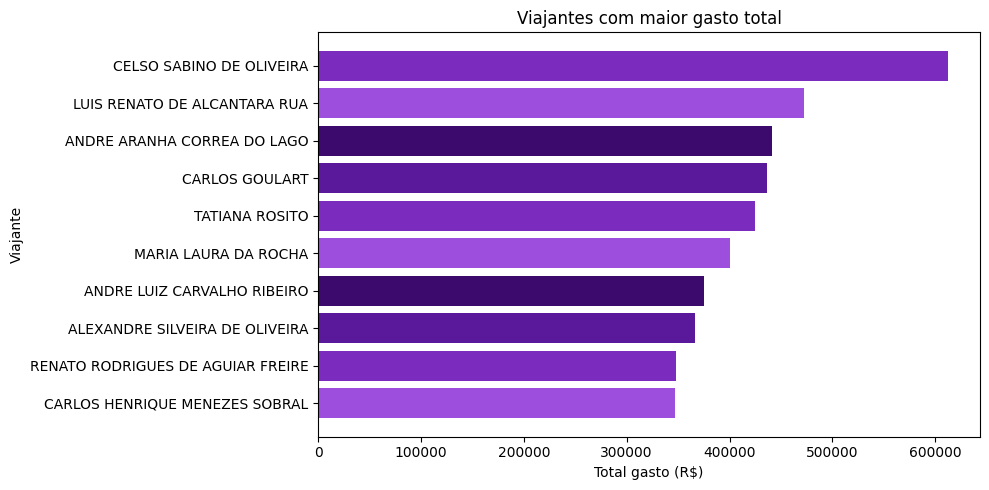

In [112]:
# Ordena para melhor visualização
df_gold1_plot = df_gold1.sort_values("total_gasto")

plt.figure(figsize=(10,5))

cores = ["#9d4edd", "#7b2cbf", "#5a189a", "#3c096c"]

plt.barh(
    df_gold1_plot["nome_viajante"],
    df_gold1_plot["total_gasto"],
    color=cores[:len(df_gold1_plot)]
)

plt.title("Viajantes com maior gasto total")
plt.xlabel("Total gasto (R$)")
plt.ylabel("Viajante")

plt.tight_layout()
plt.show()

A análise inicial identificou grande concentração de gastos em categorias como "Informações protegidas por sigilo" e "Sem Informação", que não representam indivíduos específicos.

Após o tratamento desses registros, observa-se que determinados viajantes concentram maior volume de gastos, indicando possível maior frequência de deslocamentos ou participação em viagens de maior custo.

### Pergunta Gold 2 — Quais órgãos possuem maior custo médio por viagem?

In [115]:
query_gold2 = """
SELECT 
    nome_orgao_pagador,
    AVG(total_pago) AS custo_medio
FROM gold_viagens
WHERE nome_orgao_pagador NOT IN ('Sem Informação', 'Sigiloso')
GROUP BY nome_orgao_pagador
ORDER BY custo_medio DESC
LIMIT 10;
"""

In [116]:
# Executa a consulta e retorna o resultado em DataFrame

conexao = conectar()

try:
    df_gold2 = pd.read_sql(query_gold2, conexao)
finally:
    conexao.close()

df_gold2

C:\Users\windows_user\AppData\Local\Temp\ipykernel_11196\63806791.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_gold2 = pd.read_sql(query_gold2, conexao)


,nome_orgao_pagador,custo_medio
0,Ministério das Relações Exteriores - Unidades ...,13287.688832
1,Ministério da Justiça e Segurança Pública - Un...,11937.679725
2,Fundo Nacional de Segurança Pública,11547.563771
3,Agência Nacional de Vigilância Sanitária,11195.073314
4,Ministério do Turismo - Unidades com vínculo d...,10614.851607
5,Autoridade Nacional de Proteção de Dados,8702.788367
6,Ministério das Comunicações - Unidades com vín...,8629.573721
7,Conselho Administrativo de Defesa Econômica,8489.616794
8,Ministério de Minas e Energia - Unidades com v...,8138.919696
9,Ministério do Esporte - Unidades com vínculo d...,7997.754234


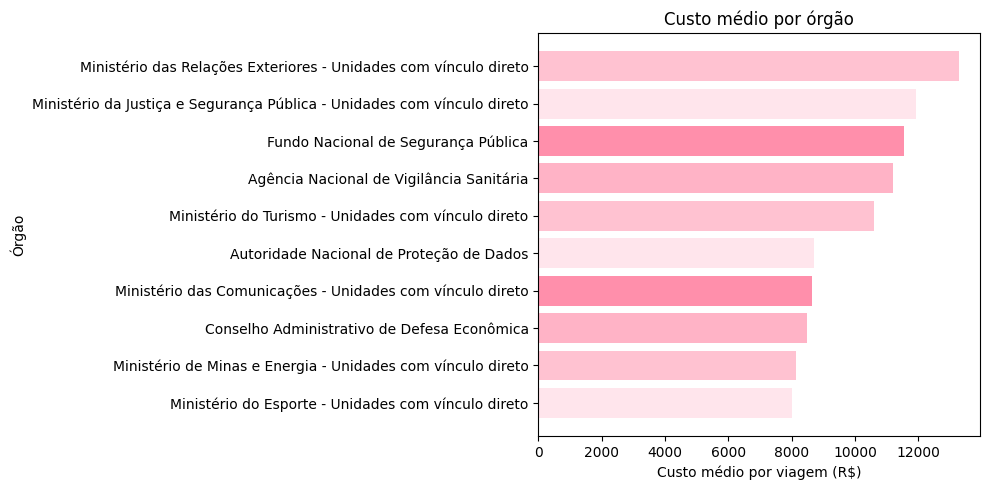

In [ ]:
# Ordena para visualização
df_gold2_plot = df_gold2.sort_values("custo_medio")

plt.figure(figsize=(10,5))


cores = ["#ffe5ec", "#ffc2d1", "#ffb3c6", "#ff8fab"]

plt.barh(
    df_gold2_plot["nome_orgao_pagador"],
    df_gold2_plot["custo_medio"],
    color=cores[:len(df_gold2_plot)]
)

plt.title("Custo médio por órgão")
plt.xlabel("Custo médio por viagem (R$)")
plt.ylabel("Órgão")

plt.tight_layout()
plt.show()

Determinados órgãos apresentam custo médio por viagem superior aos demais, indicando deslocamentos potencialmente mais longos ou com maior complexidade logística.

Ao utilizar a média, a análise evita distorções causadas por órgãos com grande volume total de gastos, permitindo uma comparação mais equilibrada entre diferentes instituições.

### Pergunta Gold 3 — Quais destinos concentram maior volume total de gastos?

In [120]:
query_gold3 = """
SELECT 
    destinos,
    SUM(total_pago) AS total_gasto
FROM gold_viagens
WHERE destinos NOT IN (
    'Informações protegidas por sigilo',
    'Sem informação'
)
AND destinos IS NOT NULL
GROUP BY destinos
ORDER BY total_gasto DESC
LIMIT 10;
"""

In [121]:
# Executa a consulta e retorna o resultado em DataFrame

conexao = conectar()

try:
    df_gold3 = pd.read_sql(query_gold3, conexao)
finally:
    conexao.close()

df_gold3

C:\Users\windows_user\AppData\Local\Temp\ipykernel_11196\3479793300.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_gold3 = pd.read_sql(query_gold3, conexao)


,destinos,total_gasto
0,Brasília/DF,1.088935e+08
1,Rio de Janeiro/RJ,3.681393e+07
2,São Paulo/SP,2.987108e+07
3,São José dos Campos/SP,1.630166e+07
4,Manaus/AM,1.281562e+07
5,Foz do Iguaçu/PR,1.099543e+07
6,Boa Vista/RR,1.075559e+07
7,Belo Horizonte/MG,1.024435e+07
8,Recife/PE,9.624624e+06
9,"Brasília/DF, Brasília/DF, Brasília/DF, Brasíli...",9.616719e+06


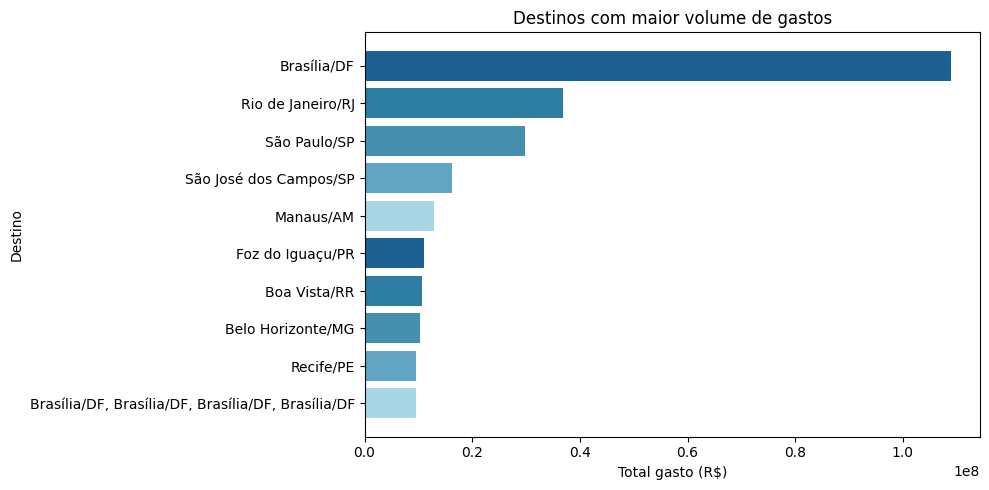

In [122]:
# Ordena para visualização (top 10 já filtrado)
df_gold3_plot = df_gold3.sort_values("total_gasto")

plt.figure(figsize=(10,5))

cores = ["#a9d6e5", "#61a5c2", "#468faf", "#2c7da0", "#1e6091"]

plt.barh(
    df_gold3_plot["destinos"],
    df_gold3_plot["total_gasto"],
    color=cores[:len(df_gold3_plot)]
)

plt.title("Destinos com maior volume de gastos")
plt.xlabel("Total gasto (R$)")
plt.ylabel("Destino")

plt.tight_layout()
plt.show()

A análise inicial identificou a presença de registros classificados como "Informações protegidas por sigilo", que não representam destinos reais e foram desconsiderados na interpretação dos resultados.

Após o tratamento, os dados mostram forte concentração de gastos em destinos como Brasília, Rio de Janeiro e São Paulo, indicando polos estratégicos de deslocamento institucional.

Esse padrão reflete a centralização administrativa e econômica, além da relevância dessas localidades para atividades governamentais.

## Conclusão


Ao longo da análise, foi possível identificar alguns padrões nos dados de viagens, principalmente em relação aos destinos mais frequentes e aos órgãos com maiores gastos.

Brasília, por exemplo, aparece com destaque, o que faz sentido por ser o principal centro administrativo do país. Também foi possível perceber diferenças no custo médio entre órgãos, o que pode estar relacionado ao tipo de deslocamento realizado.

Outro ponto importante foi a presença de dados como “Sigiloso” ou “Sem informação”, que precisaram ser tratados para não distorcer os resultados.

No geral, o projeto mostra como dados brutos podem ser transformados em informações mais úteis, ajudando a entender melhor o comportamento dos gastos públicos.